## 1. Definición del problema de negocio

## Problema

Las empresas de la industria cinematográfica y las plataformas de streaming
reciben grandes cantidades de críticas y opiniones sobre sus contenidos.
Analizar manualmente este volumen de información resulta complejo y poco
escalable.

## Objetivo

Desarrollar un pipeline escalable de Deep Learning basado en procesamiento
de lenguaje natural (NLP) que permita clasificar automáticamente las reviews
cinematográficas como Fresh o Rotten a partir del texto escrito por los críticos.

## Aplicación de negocio

La solución permitiría transformar grandes cantidades de texto no estructurado
en información cuantificable que pueda ser utilizada para monitorear la
percepción de contenidos y apoyar decisiones de marketing y gestión de contenido.

In [ ]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para gráficos
import matplotlib.pyplot as plt

# TensorFlow / Keras para Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Métricas de evaluación
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Configuración para visualizar más texto en pandas
pd.set_option("display.max_colwidth", 200)

# Mostrar versión de TensorFlow
print("Versión TensorFlow:", tf.__version__)

# Verificar si Colab está utilizando GPU
print("GPU disponibles:", tf.config.list_physical_devices("GPU"))

Versión TensorFlow: 2.20.0
GPU disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carga y exploración de los datos

In [ ]:
# ============================================================
# 2. CARGAR EL DATASET
# ============================================================

# Ruta donde se encuentra el archivo CSV
file_path = "/content/rotten_tomatoes_movie_reviews.csv.zip"

df = pd.read_csv(file_path)

# Mostrar dimensiones del dataset
print("Filas y columnas:", df.shape)

# Mostrar las primeras filas
df.head()

Filas y columnas: (1444963, 11)


,id,reviewId,creationDate,criticName,isTopCritic,originalScore,reviewState,publicatioName,reviewText,scoreSentiment,reviewUrl
0,beavers,1145982,2003-05-23,Ivan M. Lincoln,False,3.5/4,fresh,Deseret News (Salt Lake City),"Timed to be just long enough for most youngsters' brief attention spans -- and it's packed with plenty of interesting activity, both on land and under the water.",POSITIVE,http://www.deseretnews.com/article/700003233/Beavers.html
1,blood_mask,1636744,2007-06-02,The Foywonder,False,1/5,rotten,Dread Central,"It doesn't matter if a movie costs 300 million or only 300 dollars; good is good and bad is bad, and Bloodmask: The Possession of Nicole Lameroux is just plain bad.",NEGATIVE,http://www.dreadcentral.com/index.php?name=Reviews&req=showcontent&id=1466
2,city_hunter_shinjuku_private_eyes,2590987,2019-05-28,Reuben Baron,False,NaN,fresh,CBR,"The choreography is so precise and lifelike at points one might wonder whether the movie was rotoscoped, but no live-action reference footage was used. The quality is due to the skill of the anima...",POSITIVE,https://www.cbr.com/city-hunter-shinjuku-private-eyes-review/
3,city_hunter_shinjuku_private_eyes,2558908,2019-02-14,Matt Schley,False,2.5/5,rotten,Japan Times,The film's out-of-touch attempts at humor may find them hunting for the reason the franchise was so popular in the first place.,NEGATIVE,https://www.japantimes.co.jp/culture/2019/02/06/films/film-reviews/city-hunter-movie-shinjuku-private-eyes-dated-gags-modern-day-tokyo/#.XGXYvJNKjOS
4,dangerous_men_2015,2504681,2018-08-29,Pat Padua,False,NaN,fresh,DCist,Its clumsy determination is endearing and sometimes wildly entertaining,POSITIVE,http://dcist.com/2015/11/out_of_frame_dangerous_men.php


In [ ]:
# ============================================================
# 3. EXPLORACIÓN INICIAL
# ============================================================

# Mostrar nombres de todas las columnas
print(df.columns.tolist())

['id', 'reviewId', 'creationDate', 'criticName', 'isTopCritic', 'originalScore', 'reviewState', 'publicatioName', 'reviewText', 'scoreSentiment', 'reviewUrl']


In [ ]:
# Revisar información general:
# tipo de dato, cantidad de registros, valores no nulos, etc.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1444963 entries, 0 to 1444962
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   id              1444963 non-null  object
 1   reviewId        1444963 non-null  int64 
 2   creationDate    1444963 non-null  object
 3   criticName      1444963 non-null  object
 4   isTopCritic     1444963 non-null  bool  
 5   originalScore   1009745 non-null  object
 6   reviewState     1444963 non-null  object
 7   publicatioName  1444963 non-null  object
 8   reviewText      1375738 non-null  object
 9   scoreSentiment  1444963 non-null  object
 10  reviewUrl       1234038 non-null  object
dtypes: bool(1), int64(1), object(9)
memory usage: 111.6+ MB


In [ ]:
# ============================================================
# 4. SELECCIONAR VARIABLES IMPORTANTES
# ============================================================

columnas = [
    "reviewText",
    "reviewState",
    "creationDate",
    "isTopCritic",
    "publicatioName"
]

df = df[columnas].copy()

df.head()

,reviewText,reviewState,creationDate,isTopCritic,publicatioName
0,"Timed to be just long enough for most youngsters' brief attention spans -- and it's packed with plenty of interesting activity, both on land and under the water.",fresh,2003-05-23,False,Deseret News (Salt Lake City)
1,"It doesn't matter if a movie costs 300 million or only 300 dollars; good is good and bad is bad, and Bloodmask: The Possession of Nicole Lameroux is just plain bad.",rotten,2007-06-02,False,Dread Central
2,"The choreography is so precise and lifelike at points one might wonder whether the movie was rotoscoped, but no live-action reference footage was used. The quality is due to the skill of the anima...",fresh,2019-05-28,False,CBR
3,The film's out-of-touch attempts at humor may find them hunting for the reason the franchise was so popular in the first place.,rotten,2019-02-14,False,Japan Times
4,Its clumsy determination is endearing and sometimes wildly entertaining,fresh,2018-08-29,False,DCist


In [ ]:
# ============================================================
# 5. ANALIZAR DATOS FALTANTES
# ============================================================

# Contar valores nulos por columna
nulos = df.isnull().sum()

print(nulos)

reviewText        69225
reviewState           0
creationDate          0
isTopCritic           0
publicatioName        0
dtype: int64


In [ ]:
# Calcular porcentaje de valores nulos

porcentaje_nulos = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

porcentaje_nulos

,0
reviewText,4.79078
reviewState,0.00000
creationDate,0.00000
isTopCritic,0.00000
publicatioName,0.00000


### Análisis de valores nulos

Se revisó la presencia de valores faltantes en las variables seleccionadas.
Para el entrenamiento del modelo son indispensables `reviewText` y
`reviewState`, por lo que los registros que no contienen información en
estas variables serán eliminados.

In [ ]:
# ============================================================
# 6. LIMPIEZA DE DATOS
# ============================================================

# Eliminar filas donde reviewText o reviewState tengan valores nulos
df = df.dropna(
    subset=[
        "reviewText",
        "reviewState"
    ]
)

print("Registros después de eliminar nulos:", len(df))

Registros después de eliminar nulos: 1375738


In [ ]:
# Ver qué valores existen en reviewState

df["reviewState"].value_counts()

,count
reviewState,
fresh,922510
rotten,453228


In [ ]:
# Convertimos todos los valores a minúsculas
# y eliminamos espacios innecesarios.

df["reviewState"] = (
    df["reviewState"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["reviewState"].value_counts()

,count
reviewState,
fresh,922510
rotten,453228


In [ ]:
# ============================================================
# 8. FILTRAR CLASES
# ============================================================

df = df[
    df["reviewState"].isin(
        ["fresh", "rotten"]
    )
].copy()

print(df["reviewState"].value_counts())

reviewState
fresh     922510
rotten    453228
Name: count, dtype: int64


In [ ]:
# ============================================================
# 9. CREAR VARIABLE OBJETIVO
# ============================================================

df["label"] = df["reviewState"].map(
    {
        "fresh": 1,
        "rotten": 0
    }
)

# Revisar resultado
df[
    [
        "reviewText",
        "reviewState",
        "label"
    ]
].head()

,reviewText,reviewState,label
0,"Timed to be just long enough for most youngsters' brief attention spans -- and it's packed with plenty of interesting activity, both on land and under the water.",fresh,1
1,"It doesn't matter if a movie costs 300 million or only 300 dollars; good is good and bad is bad, and Bloodmask: The Possession of Nicole Lameroux is just plain bad.",rotten,0
2,"The choreography is so precise and lifelike at points one might wonder whether the movie was rotoscoped, but no live-action reference footage was used. The quality is due to the skill of the anima...",fresh,1
3,The film's out-of-touch attempts at humor may find them hunting for the reason the franchise was so popular in the first place.,rotten,0
4,Its clumsy determination is endearing and sometimes wildly entertaining,fresh,1


In [ ]:
# ============================================================
# 10. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================

conteo = df["reviewState"].value_counts()

print(conteo)
porcentaje = (
    df["reviewState"]
    .value_counts(normalize=True)
    * 100
)

print(porcentaje)

reviewState
fresh     922510
rotten    453228
Name: count, dtype: int64
reviewState
fresh     67.055646
rotten    32.944354
Name: proportion, dtype: float64


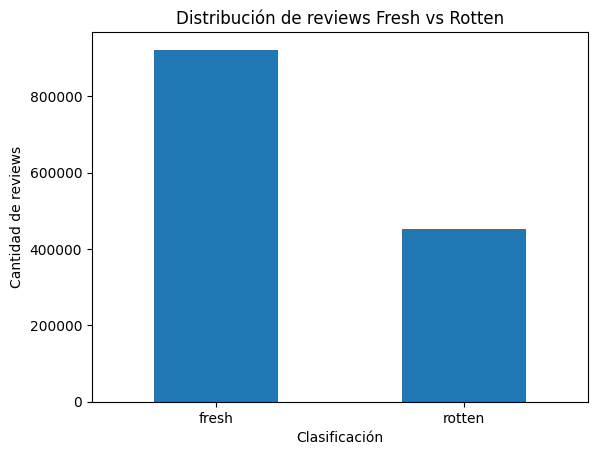

In [ ]:
# Gráfico de distribución

df["reviewState"].value_counts().plot(
    kind="bar"
)

plt.title("Distribución de reviews Fresh vs Rotten")
plt.xlabel("Clasificación")
plt.ylabel("Cantidad de reviews")
plt.xticks(rotation=0)
plt.show()

### Distribución de clases

Se analiza la proporción de críticas clasificadas como Fresh y Rotten.
Esta revisión es importante para determinar si existe un desbalance
significativo entre las clases, ya que un fuerte desbalance podría afectar
la capacidad predictiva del modelo.

In [ ]:
# ============================================================
# 11. LONGITUD DE LAS REVIEWS
# ============================================================

# Crear una variable con cantidad de caracteres
df["review_length"] = (
    df["reviewText"]
    .astype(str)
    .str.len()
)

df["review_length"].describe()

,review_length
count,1.375738e+06
mean,1.315793e+02
std,5.679759e+01
min,1.000000e+00
25%,8.900000e+01
50%,1.300000e+02
75%,1.710000e+02
max,3.630000e+02


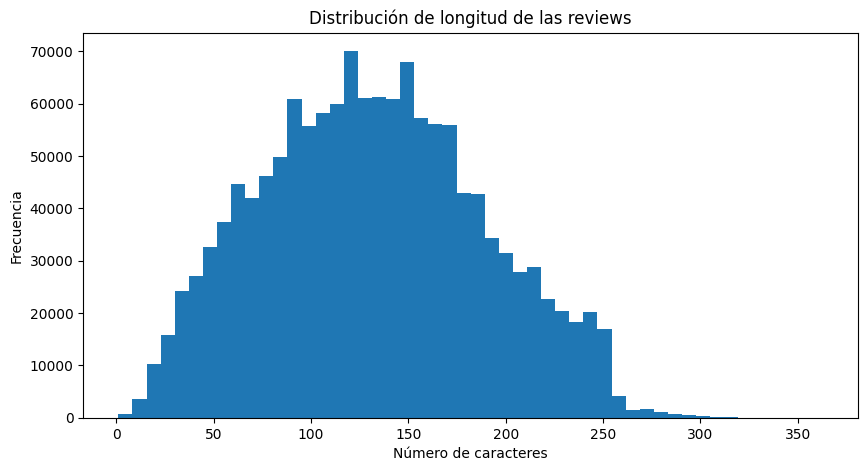

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    df["review_length"],
    bins=50
)

plt.title("Distribución de longitud de las reviews")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")

plt.show()

In [ ]:
# Revisar distribución Top Critic

df["isTopCritic"].value_counts(dropna=False)

,count
isTopCritic,
False,949438
True,426300


In [ ]:
pd.crosstab(
    df["isTopCritic"],
    df["reviewState"],
    normalize="index"
) * 100

reviewState,fresh,rotten
isTopCritic,,
False,68.753515,31.246485
True,63.274220,36.725780


### Análisis de críticos

Se analiza si los críticos considerados "Top Critics" presentan patrones
de clasificación distintos al resto. Este análisis puede permitir identificar
diferencias en el comportamiento o nivel de exigencia entre grupos de críticos.

In [ ]:
# ============================================================
# 13. PUBLICACIONES CON MAYOR CANTIDAD DE REVIEWS
# ============================================================

df["publicatioName"].value_counts().head(10)

,count
publicatioName,
New York Times,19646
Variety,17572
Los Angeles Times,14347
Hollywood Reporter,13710
Dennis Schwartz Movie Reviews,13124
Slant Magazine,11763
Guardian,11159
Common Sense Media,10882
Village Voice,10684


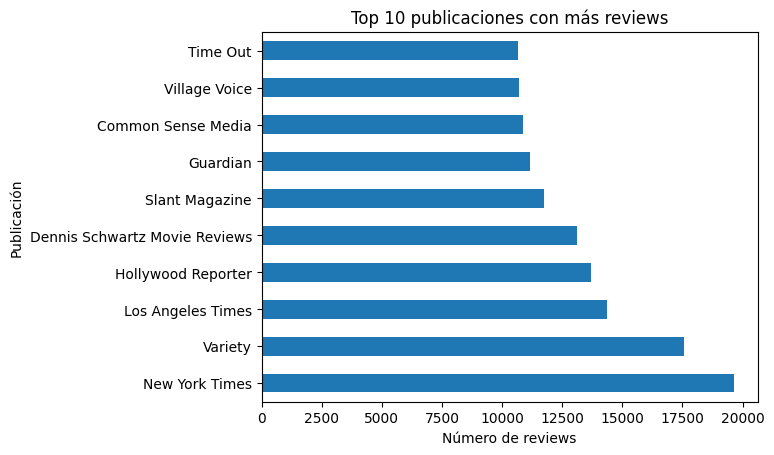

In [ ]:
df["publicatioName"].value_counts().head(10).plot(
    kind="barh"
)

plt.title("Top 10 publicaciones con más reviews")
plt.xlabel("Número de reviews")
plt.ylabel("Publicación")

plt.show()

# 3. Limpieza y preparación de los datos
En esta etapa los datos son preparados para el entrenamiento del modelo.

Las reviews se ordenan cronológicamente y posteriormente se dividen en conjuntos
de entrenamiento, validación y prueba.

Además, se utiliza tf.data para crear un pipeline que permita procesar los datos
mediante batches de manera eficiente.

In [ ]:
# ============================================================
# 14. CONVERTIR creationDate A FECHA
# ============================================================

df["creationDate"] = pd.to_datetime(
    df["creationDate"],
    errors="coerce"
)

# Eliminar registros donde no se pudo identificar la fecha
df = df.dropna(
    subset=["creationDate"]
)

df["creationDate"].describe()

,creationDate
count,1375738
mean,2013-09-05 09:32:26.898028032
min,1800-01-01 00:00:00
25%,2008-01-22 00:00:00
50%,2014-12-11 00:00:00
75%,2019-07-15 00:00:00
max,2023-04-08 00:00:00


In [ ]:
# Ordenar desde las reviews más antiguas
# hasta las más recientes

df = (
    df
    .sort_values("creationDate")
    .reset_index(drop=True)
)

df.head()

,reviewText,reviewState,creationDate,isTopCritic,publicatioName,label,review_length
0,The choreographed routines and editing have such dizzy energy they carry it aloft.,fresh,1800-01-01,True,Daily Telegraph (UK),1,82
1,"All in all, AIrborne is not bad for what it is, but what it is is very little.",rotten,1800-01-01,True,Austin Chronicle,0,78
2,"'Every Day,' while enjoyable, feels very much like the work of a writer/director best known for slick, well-made television.",fresh,1800-01-01,True,DVDTalk.com,1,124
3,"A bright, cheery pop confection, the entertaining tale of ""how one man changed the world with a pair of scissors.""",fresh,1800-01-01,True,DVDTalk.com,1,114
4,"It's as effective in 2009 as it was upon its initial release, and the richness of its tapestry, densely woven from human emotions and character interaction, ensure it will never lose that relevance.",fresh,1800-01-01,True,ReelViews,1,198


In [ ]:
# ============================================================
# 16. DIVISIÓN DEL DATASET
# ============================================================

n = len(df)

train_end = int(n * 0.80)
val_end = int(n * 0.90)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (1100590, 7)
Validation: (137574, 7)
Test: (137574, 7)


In [ ]:
print(
    "Train:",
    train_df["creationDate"].min(),
    "-",
    train_df["creationDate"].max()
)

print(
    "Validation:",
    val_df["creationDate"].min(),
    "-",
    val_df["creationDate"].max()
)

print(
    "Test:",
    test_df["creationDate"].min(),
    "-",
    test_df["creationDate"].max()
)

Train: 1800-01-01 00:00:00 - 2020-03-19 00:00:00
Validation: 2020-03-19 00:00:00 - 2021-09-03 00:00:00
Test: 2021-09-03 00:00:00 - 2023-04-08 00:00:00


### División de datos

El dataset se divide de manera cronológica utilizando 80% para entrenamiento,
10% para validación y 10% para prueba.

Esta estrategia permite simular un escenario real en el cual el modelo
aprende utilizando reviews históricas y posteriormente debe clasificar
reviews más recientes que no observó durante el entrenamiento.

In [ ]:
# ============================================================
# 17. CREAR PIPELINE TF.DATA
# ============================================================

# Número de registros procesados simultáneamente
BATCH_SIZE = 256

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_df["reviewText"].astype(str).values,
        train_df["label"].values
    )
)

In [ ]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_df["reviewText"].astype(str).values,
        val_df["label"].values
    )
)

In [ ]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["reviewText"].astype(str).values,
        test_df["label"].values
    )
)

In [ ]:
# ============================================================
# 18. OPTIMIZAR EL PIPELINE
# ============================================================

# Shuffle mezcla los datos de entrenamiento
# para evitar que la red aprenda según el orden.

train_ds = (
    train_ds
    .shuffle(50000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation y Test no necesitan shuffle

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

### Pipeline con tf.data

Para mejorar la eficiencia del procesamiento se utiliza `tf.data`.

El dataset es procesado mediante batches, lo que evita cargar todos los
registros simultáneamente durante el entrenamiento.

Además, `prefetch()` prepara el siguiente lote de información mientras el
modelo procesa el lote actual, permitiendo aprovechar mejor los recursos
computacionales disponibles.

# 4. Pipeline de procesamiento de texto (NLP)

Las redes neuronales no pueden procesar directamente texto, por lo que las
reviews deben transformarse en representaciones numéricas.

Para ello se utiliza TextVectorization, que construye un vocabulario a partir
de los datos de entrenamiento y transforma cada review en una secuencia de
tokens numéricos.

In [ ]:
# ============================================================
# 19. TOKENIZACIÓN DEL TEXTO
# ============================================================

# Número máximo de palabras diferentes
MAX_TOKENS = 30000

# Número máximo de tokens por review
SEQUENCE_LENGTH = 200

In [ ]:
vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

In [ ]:
# Extraemos únicamente el texto del dataset de entrenamiento

train_text = train_ds.map(
    lambda text, label: text
)

In [ ]:
# ============================================================
# 21. APRENDER VOCABULARIO
# ============================================================

vectorizer.adapt(train_text)

print("Vocabulario creado correctamente.")

Vocabulario creado correctamente.


In [ ]:
vocabulary = vectorizer.get_vocabulary()

print("Tamaño del vocabulario:", len(vocabulary))

print(
    "Primeras palabras:",
    vocabulary[:30]
)

Tamaño del vocabulario: 30000
Primeras palabras: ['', '[UNK]', np.str_('the'), np.str_('a'), np.str_('and'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('its'), np.str_('that'), np.str_('it'), np.str_('as'), np.str_('but'), np.str_('with'), np.str_('this'), np.str_('for'), np.str_('film'), np.str_('an'), np.str_('on'), np.str_('movie'), np.str_('be'), np.str_('you'), np.str_('not'), np.str_('by'), np.str_('at'), np.str_('one'), np.str_('are'), np.str_('from'), np.str_('more')]


In [ ]:
# ============================================================
# 23. EJEMPLO DE TOKENIZACIÓN
# ============================================================

ejemplo = tf.constant([
    "This movie was absolutely fantastic and the performances were excellent"
])

vectorizado = vectorizer(ejemplo)

print(vectorizado)

tf.Tensor(
[[ 15  20  70 744 895   4   2 113 174 525   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]], shape=(1, 200), dtype=int64)


### Tokenización

La capa `TextVectorization` transforma cada palabra del texto en un número.

Por ejemplo, una frase como:

"This movie was absolutely fantastic"

puede convertirse en una secuencia como:

[15, 72, 28, 954, 382, ...]

Posteriormente estos tokens serán transformados en representaciones
vectoriales mediante una capa Embedding.

# 5. Arquitectura del modelo Deep Learning

Se construye una red neuronal orientada al procesamiento de secuencias de texto.

La arquitectura combina TextVectorization, Embedding, Bidirectional LSTM,
Dropout y capas Dense para realizar una clasificación binaria entre Fresh
y Rotten.

In [ ]:
# ============================================================
# 24. CREACIÓN DEL MODELO DE DEEP LEARNING
# ============================================================

model = keras.Sequential([

    # Entrada: texto
    layers.Input(
        shape=(
        ),
        dtype=tf.string
    ),

    # Convertir palabras en tokens numéricos
    vectorizer,

    # Convertir cada token en un vector
    layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=128,
        mask_zero=True
    ),

    # LSTM bidireccional:
    # analiza el texto de izquierda a derecha
    # y de derecha a izquierda
    layers.Bidirectional(
        layers.LSTM(64, use_cudnn=False)
    ),

    # Reduce el riesgo de overfitting
    layers.Dropout(0.4),

    # Capa neuronal totalmente conectada
    layers.Dense(
        64,
        activation="relu"
    ),

    # Segunda regularización
    layers.Dropout(0.3),

    # Una neurona porque es clasificación binaria.
    # Sigmoid devuelve una probabilidad entre 0 y 1.
    layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,137 (15.06 MB)

 Trainable params: 3,947,137 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# 26. COMPILAR MODELO
# ============================================================

model.compile(

    # Adam ajusta automáticamente los pesos
    optimizer="adam",

    # Función de pérdida apropiada
    # para clasificación binaria
    loss="binary_crossentropy",

    # Métricas que queremos monitorear
    metrics=[
        "accuracy",

        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        ),

        keras.metrics.AUC(
            name="auc"
        )
    ]
)

In [ ]:
# ============================================================
# 27. EARLY STOPPING
# ============================================================

# Detendrá el entrenamiento si val_loss
# deja de mejorar durante 2 épocas.

early_stopping = keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=2,

    # Recuperar los mejores pesos encontrados
    restore_best_weights=True
)

In [ ]:
# Guardará el modelo con menor validation loss

checkpoint = keras.callbacks.ModelCheckpoint(

    "best_movie_model.keras",

    monitor="val_loss",

    save_best_only=True
)

In [ ]:
# ============================================================
# COMPILAR EL MODELO ANTES DE ENTRENAR
# ============================================================

model.compile(
    # Optimizador que ajustará los pesos de la red neuronal
    optimizer="adam",

    # Como tenemos dos clases:
    # 0 = Rotten
    # 1 = Fresh
    # usamos binary_crossentropy
    loss="binary_crossentropy",

    # Métricas que queremos observar durante el entrenamiento
    metrics=[
        "accuracy",

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

print("Modelo compilado correctamente.")

Modelo compilado correctamente.


In [ ]:
# ============================================================
# CREAR Y COMPILAR EL MODELO
# Ejecutar antes de la Parte 29
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Crear el modelo
model = keras.Sequential([

    # Entrada: texto de la review
    layers.Input(
        shape=(),
        dtype=tf.string
    ),

    # Convierte el texto en números
    vectorizer,

    # Convierte cada palabra en un vector
    layers.Embedding(
        input_dim=MAX_TOKENS,
        output_dim=128,
        mask_zero=True
    ),

    # Red neuronal LSTM bidireccional
    layers.Bidirectional(
        layers.LSTM(64, use_cudnn=False) # Corregido: Añadir use_cudnn=False
    ),

    # Regularización para evitar overfitting
    layers.Dropout(0.4),

    # Capa oculta
    layers.Dense(
        64,
        activation="relu"
    ),

    # Segunda regularización
    layers.Dropout(0.3),

    # Salida:
    # 0 = Rotten
    # 1 = Fresh
    layers.Dense(
        1,
        activation="sigmoid"
    )
])


# ============================================================
# COMPILAR EL MODELO
# ============================================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc")
    ]
)

print("Modelo creado y compilado correctamente.")

model.summary()

Modelo creado y compilado correctamente.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,137 (15.06 MB)

 Trainable params: 3,947,137 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

# 6. Entrenamiento y validación del modelo

El modelo es entrenado utilizando las reviews del conjunto de entrenamiento
y evaluado durante cada época utilizando el conjunto de validación.

Se monitorean métricas como Accuracy y Loss para determinar si el modelo está
aprendiendo correctamente y detectar posibles problemas de overfitting.

In [ ]:
# ============================================================
# 29. ENTRENAMIENTO
# ============================================================

history = model.fit(

    train_ds,

    validation_data=val_ds,

    # Para la prueba usamos pocas épocas
    epochs=3,

    # Solo procesamos 300 batches por época
    # en lugar de los 4300 completos
    steps_per_epoch=300,

    # También reducimos la validación
    validation_steps=50,

    callbacks=[
        early_stopping,
        checkpoint
    ],

    verbose=1
)

Epoch 1/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 272s 905ms/step - accuracy: 0.9001 - auc: 0.9633 - loss: 0.2406 - precision: 0.9151 - recall: 0.9170 - val_accuracy: 0.8561 - val_auc: 0.9186 - val_loss: 0.3382 - val_precision: 0.9272 - val_recall: 0.8749
Epoch 2/3
300/300 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.8950 - auc: 0.9595 - loss: 0.2513 - precision: 0.9123 - recall: 0.9154 - val_accuracy: 0.8512 - val_auc: 0.9161 - val_loss: 0.3395 - val_precision: 0.9230 - val_recall: 0.8724


In [ ]:
# ============================================================
# 30. HISTORIAL DEL ENTRENAMIENTO
# ============================================================

history_df = pd.DataFrame(
    history.history
)

history_df

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
0,0.900065,0.963321,0.240650,0.915135,0.916959,0.856094,0.918583,0.338166,0.927210,0.874934
1,0.895013,0.959458,0.251264,0.912268,0.915412,0.851172,0.916119,0.339531,0.922991,0.872410


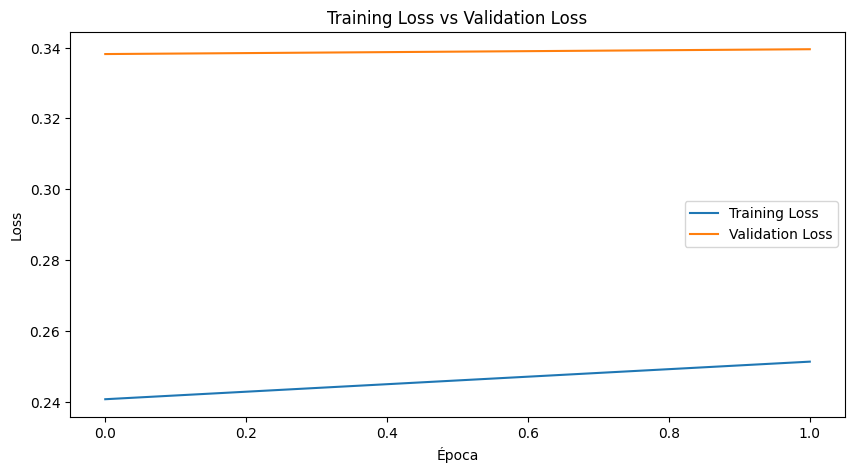

In [ ]:
# ============================================================
# Gráfico Loss
# ============================================================
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training Loss vs Validation Loss")

plt.xlabel("Época")
plt.ylabel("Loss")

plt.legend()

plt.show()

### Interpretación de Loss

La pérdida representa el error cometido por el modelo.

Lo esperado es que tanto el error de entrenamiento como el de validación
disminuyan durante las primeras épocas.

Si el error de entrenamiento continúa disminuyendo pero el de validación
empieza a aumentar, podría indicar que el modelo está sufriendo overfitting.

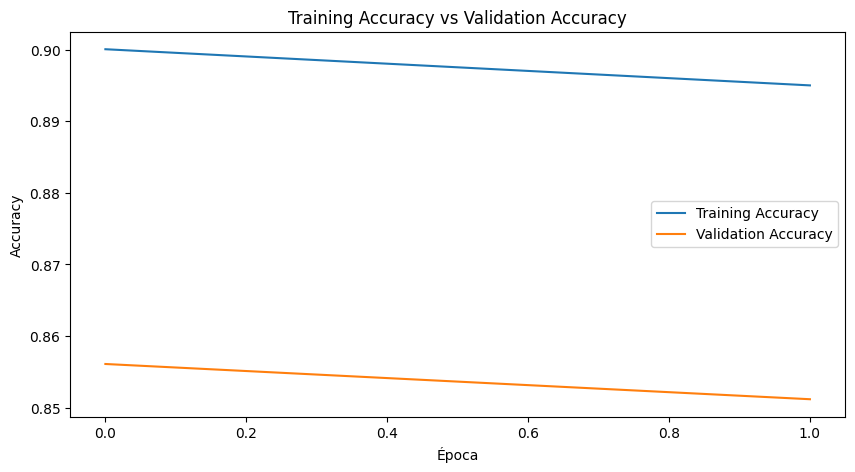

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Training Accuracy vs Validation Accuracy"
)

plt.xlabel("Época")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

# 7. Evaluación e interpretación del modelo

Una vez finalizado el entrenamiento, el modelo es evaluado utilizando el
conjunto Test, compuesto por reviews que no fueron utilizadas para entrenar
la red neuronal.

Se utilizan diferentes métricas para analizar su capacidad de clasificación,
incluyendo Accuracy, Precision, Recall, F1-score, AUC y matriz de confusión.

In [ ]:
# ============================================================
# 33. EVALUACIÓN FINAL
# ============================================================

results = model.evaluate(
    test_ds,
    return_dict=True
)

results

538/538 ━━━━━━━━━━━━━━━━━━━━ 110s 204ms/step - accuracy: 0.8319 - auc: 0.9071 - loss: 0.3809 - precision: 0.9324 - recall: 0.8364


{'accuracy': 0.8318504691123962,
 'auc': 0.907102108001709,
 'loss': 0.3808971047401428,
 'precision': 0.9324017763137817,
 'recall': 0.8363821506500244}

In [ ]:
print(
    "Accuracy:",
    round(results["accuracy"], 4)
)

print(
    "Precision:",
    round(results["precision"], 4)
)

print(
    "Recall:",
    round(results["recall"], 4)
)

print(
    "AUC:",
    round(results["auc"], 4)
)

Accuracy: 0.8319
Precision: 0.9324
Recall: 0.8364
AUC: 0.9071


In [ ]:
# ============================================================
# 34. PREDICCIONES SOBRE TEST
# ============================================================

# El modelo devuelve probabilidades
pred_prob = model.predict(
    test_ds
).ravel()

pred_prob[:10]

538/538 ━━━━━━━━━━━━━━━━━━━━ 108s 201ms/step


array([0.00307987, 0.9973097 , 0.7731432 , 0.00176877, 0.987815  ,
       0.02331668, 0.9998004 , 0.4404695 , 0.9999231 , 0.7717587 ],
      dtype=float32)

In [ ]:
y_pred = (
    pred_prob >= 0.5
).astype(int)

y_pred[:20]

array([0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0])

In [ ]:
y_true = test_df["label"].values

In [ ]:
# ============================================================
# 37. CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(

        y_true,

        y_pred,

        target_names=[
            "Rotten",
            "Fresh"
        ]
    )
)

              precision    recall  f1-score   support

      Rotten       0.63      0.82      0.71     34419
       Fresh       0.93      0.84      0.88    103155

    accuracy                           0.83    137574
   macro avg       0.78      0.83      0.80    137574
weighted avg       0.86      0.83      0.84    137574



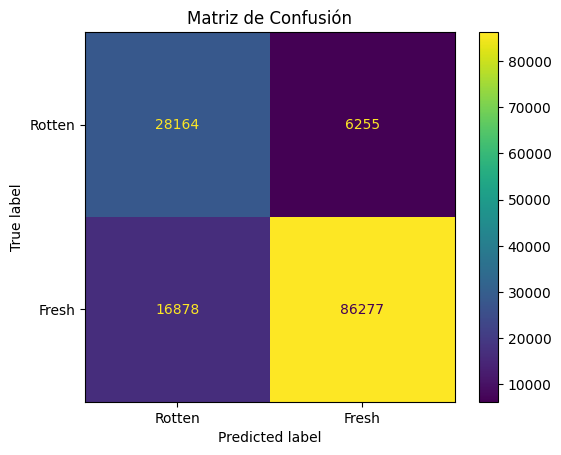

In [ ]:
# ============================================================
# 38. MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "Rotten",
        "Fresh"
    ]
)

disp.plot()

plt.title(
    "Matriz de Confusión"
)

plt.show()

### Matriz de confusión

La matriz de confusión permite observar la cantidad de reviews clasificadas
correctamente e incorrectamente.

Los valores de la diagonal representan las predicciones correctas, mientras
que los valores fuera de la diagonal representan errores de clasificación.

In [ ]:
# ============================================================
# 39. TABLA DE PREDICCIONES
# ============================================================

resultados = test_df[
    [
        "reviewText",
        "reviewState"
    ]
].copy()

resultados["prob_fresh"] = pred_prob

resultados["prediccion"] = np.where(
    y_pred == 1,
    "Fresh",
    "Rotten"
)

resultados.head(20)

,reviewText,reviewState,prob_fresh,prediccion
1238164,"the script is atrocious. It sounds like it's been improvised by the cast of ""Gilligan's Island"" or ""Jersey Shore"" - not written by one of our best playwrights (Jane Wagner).",rotten,0.003080,Rotten
1238165,A complex look at identity -- particularly as the son of immigrants... [Riz Ahmed] is at the top of his game.,fresh,0.997310,Fresh
1238166,"Child was a broadly entertaining public personality, and the film is broadly entertaining in turn...",fresh,0.773143,Fresh
1238167,"A bargain-basement, or really sub-bargain-basement, clone of 'Blade Runner, 'Zone 414' is visually tacky and almost infinitely dull.",rotten,0.001769,Rotten
1238168,Yakuza Princess is entertaining for diehard fans of the genre.,rotten,0.987815,Fresh
1238169,"An inherent lack of direction is part of the movie's appeal, but it ultimately feels lacking in the sort of incisive emotional power of other recent movies.",rotten,0.023317,Rotten
1238170,"Wife and husband directors Elizabeth Chai Vasarhelyi and Jimmy Chin are forensic in the detail they provide and the range of testimonies they have assembled; the result is a tense, absorbing docum...",fresh,0.999800,Fresh
1238171,"It's a delicious meal, but it often feels a touch undercooked.",fresh,0.440470,Rotten
1238172,A stunning documentary of bone-deep moral resonance and cinematic mastery that deserves to be experienced on the big screen.,fresh,0.999923,Fresh
1238173,Worth plugs its 9/11 drama about not treating people like numbers into a trite formula,rotten,0.771759,Fresh


In [ ]:
# Crear variable indicando si acertó

resultados["correcto"] = (
    resultados["reviewState"]
    ==
    resultados["prediccion"].str.lower()
)

errores = resultados[
    resultados["correcto"] == False
]

errores.head(20)

,reviewText,reviewState,prob_fresh,prediccion,correcto
1238168,Yakuza Princess is entertaining for diehard fans of the genre.,rotten,0.987815,Fresh,False
1238171,"It's a delicious meal, but it often feels a touch undercooked.",fresh,0.440470,Rotten,False
1238173,Worth plugs its 9/11 drama about not treating people like numbers into a trite formula,rotten,0.771759,Fresh,False
1238174,"The Last Matinee might be paying homage, but Contenti has his own story to tell and the modern twists make this more than just another gory rehash.",fresh,0.242638,Rotten,False
1238177,Black Widow achieves the unthinkable and dethrones Thor: The Dark World as the worst film in the Marvel Cinematic Universe.,rotten,0.877329,Fresh,False
1238181,"This good-looking sci-fi thriller has some fun set designs, but it also has a big ""been there, done that"" quality.",rotten,0.538594,Fresh,False
1238187,"Without involving bombastic devices involved, Parallel Mothers can be a melodrama, a thriller or a romantic comedy. [Full review in Spanish]",fresh,0.041083,Rotten,False
1238190,"""Worth"" is compelling because of the subject matter, not because of creativity on the part of the filmmakers.",rotten,0.997928,Fresh,False
1238213,"Ahmed as Zed is good, but I'm not sure that he's rapping so much as reciting slam poetry, which is bad.",fresh,0.425971,Rotten,False
1238235,"he movie's highs are enjoyable and riveting, they're reason why the character has endured for decades. But the lows - they hurt even worse.",rotten,0.830533,Fresh,False


In [ ]:
# ============================================================
# 41. FUNCIÓN DE PREDICCIÓN
# ============================================================

def predict_review(text):

    # Crear un array con el texto
    # Fix: Convertir a tf.Tensor de tipo tf.string explícitamente
    entrada = tf.constant([text], dtype=tf.string)

    # Obtener probabilidad de Fresh
    probability = float(
        model.predict(
            entrada,
            verbose=0
        )[0][0]
    )

    # Clasificación
    if probability >= 0.5:
        prediction = "FRESH"
    else:
        prediction = "ROTTEN"

    # Mostrar resultados
    print("Review:")
    print(text)

    print("\nPredicción:")
    print(prediction)

    print(
        "\nProbabilidad de Fresh:",
        round(probability * 100, 2),
        "%"
    )

In [ ]:
predict_review(
    "A brilliant movie with outstanding performances, excellent direction and a beautiful story."
)

Review:
A brilliant movie with outstanding performances, excellent direction and a beautiful story.

Predicción:
FRESH

Probabilidad de Fresh: 100.0 %


In [ ]:
predict_review(
    "The movie is boring, predictable and a complete waste of time."
)

Review:
The movie is boring, predictable and a complete waste of time.

Predicción:
ROTTEN

Probabilidad de Fresh: 0.05 %


In [ ]:
predict_review(
    "The movie has some interesting moments, but overall the story feels slow and disappointing."
)

Review:
The movie has some interesting moments, but overall the story feels slow and disappointing.

Predicción:
ROTTEN

Probabilidad de Fresh: 1.44 %


In [ ]:
def predict_api(text):

    # Fix: Convertir a tf.Tensor de tipo tf.string explícitamente
    entrada = tf.constant([text], dtype=tf.string)

    probability = float(
        model.predict(
            entrada,
            verbose=0
        )[0][0]
    )

    prediction = (
        "FRESH"
        if probability >= 0.5
        else "ROTTEN"
    )

    return {

        "prediction": prediction,

        "fresh_probability": round(
            probability,
            4
        )
    }

In [ ]:
predict_api(
    "An excellent film with brilliant acting."
)

{'prediction': 'FRESH', 'fresh_probability': 1.0}

In [ ]:
# ============================================================
# 46. GUARDAR MODELO
# ============================================================

model.save(
    "/content/movie_sentiment_model.keras"
)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.
